# LSTM Model — Household Power Consumption Forecasting

This notebook builds, trains, and evaluates an LSTM model to forecast
`Global_active_power` using the preprocessing pipeline defined in
`preprocessing.ipynb`.

Steps:
1. Load & preprocess data (same pipeline as preprocessing.ipynb)
2. Build sequences + DataLoaders
3. Define the LSTM architecture
4. Train with validation tracking + best-model checkpointing
5. Evaluate on the test set (RMSE, MAE, R²)
6. Visualize predictions vs actuals
7. Save predictions and the trained model


In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 1. Load & Preprocess Data

Same pipeline as `preprocessing.ipynb`, kept here so this notebook can run standalone.

In [2]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    na_values="?",
    low_memory=False
)

numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)
df.set_index("Datetime", inplace=True)
df.drop(columns=["Date", "Time"], inplace=True)
df.ffill(inplace=True)

# Feature engineering
df["Hour"] = df.index.hour
df["Day"] = df.index.day
df["Month"] = df.index.month
df["Year"] = df.index.year
df["Weekday"] = df.index.dayofweek

df.shape

(2075259, 12)

In [3]:
target = "Global_active_power"
features = df.columns.tolist()
features.remove(target)

X = df[features]
y = df[target]

# Time series split — no shuffling
train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1660207, 11) Test: (415052, 11)


In [4]:
# Load the scaler already fitted in preprocessing.ipynb
scaler = joblib.load("../models/scaler.pkl")

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

## 2. Sequence Dataset & DataLoaders

In [5]:
SEQ_LENGTH = 60
BATCH_SIZE = 256

class PowerDataset(Dataset):
    def __init__(self, X, y, seq_length):
        self.X = X.values.astype("float32")
        self.y = y.values.astype("float32")
        self.seq_length = seq_length

    def __len__(self):
        return len(self.X) - self.seq_length

    def __getitem__(self, idx):
        x = self.X[idx:idx + self.seq_length]
        y = self.y[idx + self.seq_length]
        return torch.tensor(x), torch.tensor(y)


train_dataset = PowerDataset(X_train_scaled, y_train, SEQ_LENGTH)
test_dataset = PowerDataset(X_test_scaled, y_test, SEQ_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=torch.cuda.is_available())

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

X_batch, y_batch = next(iter(train_loader))
print("Batch shapes:", X_batch.shape, y_batch.shape)
INPUT_SIZE = X_batch.shape[2]
print("Input feature size:", INPUT_SIZE)

Train samples: 1660147
Test samples: 414992
Batch shapes: torch.Size([256, 60, 11]) torch.Size([256])
Input feature size: 11


## 3. Validation Split

We carve a validation slice out of the *end* of the training data (still
respecting time order — no shuffling) so we can track generalization
during training without touching the held-out test set.

In [6]:
val_frac = 0.1
val_split_idx = int(len(train_dataset) * (1 - val_frac))

train_indices = list(range(0, val_split_idx))
val_indices = list(range(val_split_idx, len(train_dataset)))

from torch.utils.data import Subset

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=torch.cuda.is_available())

print("Train:", len(train_subset), "Val:", len(val_subset))

Train: 1494132 Val: 166015


## 4. LSTM Model

In [ ]:

class LSTMForecaster(nn.Module):
    def __init__(self,
                 input_size,
                 hidden_size=128,
                 num_layers=4,
                 dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)

        # Last timestep output
        out = out[:, -1, :]

        out = self.fc(out)

        return out.squeeze(-1)


model = LSTMForecaster(input_size=INPUT_SIZE).to(device)
print(model)

LSTMForecaster(
  (lstm): LSTM(11, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 5. Training Setup

In [ ]:
EPOCHS = 42
LEARNING_RATE = 1e-3
PATIENCE = 4  # early stopping patience

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)

os.makedirs("../models", exist_ok=True)
BEST_MODEL_PATH = "../models/best_model.pth"


In [9]:
def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    n_samples = 0

    torch.set_grad_enabled(is_train)
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad()

        preds = model(X_batch)
        loss = criterion(preds, y_batch)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)

    return total_loss / n_samples

## 6. Training Loop

In [10]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs_no_improve = 0

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, model, criterion, optimizer)

    with torch.no_grad():
        val_loss = run_epoch(val_loader, model, criterion, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss: {train_loss:.5f} | val_loss: {val_loss:.5f}"
        f"{'  <- best' if improved else ''}"
    )

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered after {epoch} epochs.")
        break

elapsed = time.time() - start_time
print(f"\nTraining finished in {elapsed/60:.1f} min. Best val loss: {best_val_loss:.5f}")

Epoch 01/3 | train_loss: 0.11425 | val_loss: 0.06509  <- best
Epoch 02/3 | train_loss: 0.06932 | val_loss: 0.06065  <- best
Epoch 03/3 | train_loss: 0.06390 | val_loss: 0.05784  <- best

Training finished in 54.8 min. Best val loss: 0.05784


## 7. Loss Curves

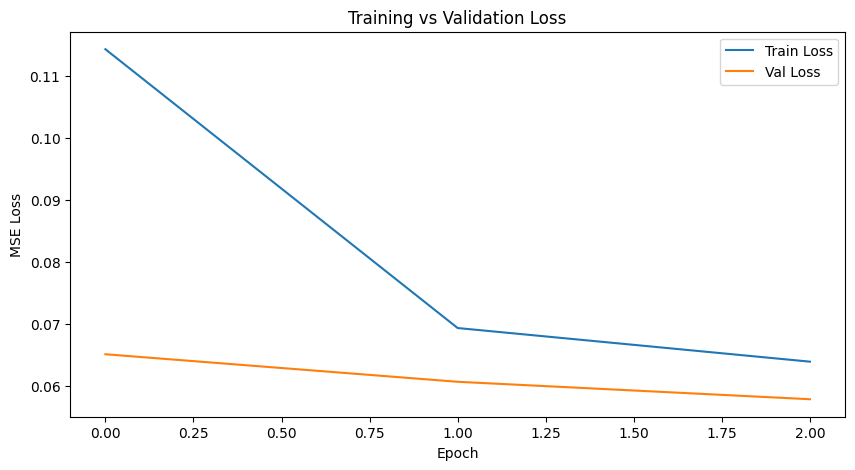

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()

os.makedirs("../outputs/plots", exist_ok=True)
plt.savefig("../outputs/plots/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Evaluate on Test Set

Load the best checkpoint (lowest validation loss) before evaluating.

In [12]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

all_preds = []
all_actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        all_preds.append(preds)
        all_actuals.append(y_batch.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_actuals)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE:  {mae:.4f}")
print(f"Test R2:   {r2:.4f}")

Test RMSE: 0.2091
Test MAE:  0.1031
Test R2:   0.9434


## 9. Predictions vs Actuals

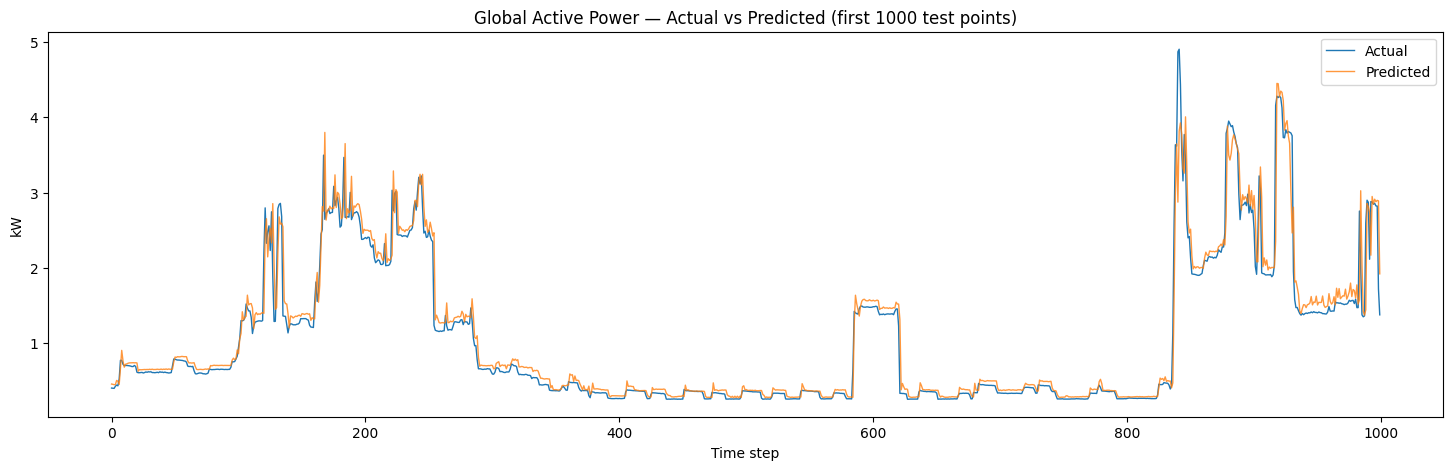

In [13]:
plt.figure(figsize=(18, 5))
plt.plot(y_true[:1000], label="Actual", linewidth=1)
plt.plot(y_pred[:1000], label="Predicted", linewidth=1, alpha=0.8)
plt.title("Global Active Power — Actual vs Predicted (first 1000 test points)")
plt.xlabel("Time step")
plt.ylabel("kW")
plt.legend()
plt.savefig("../outputs/plots/predictions_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Save Predictions

In [14]:
test_index = X_test_scaled.index[SEQ_LENGTH:]

predictions_df = pd.DataFrame({
    "Datetime": test_index,
    "Actual": y_true,
    "Predicted": y_pred
})

os.makedirs("../outputs", exist_ok=True)
predictions_df.to_csv("../outputs/predictions.csv", index=False)

predictions_df.head()

,Datetime,Actual,Predicted
0,2010-02-11 16:31:00,0.404,0.457268
1,2010-02-11 16:32:00,0.402,0.454018
2,2010-02-11 16:33:00,0.400,0.448938
3,2010-02-11 16:34:00,0.428,0.450504
4,2010-02-11 16:35:00,0.444,0.505221


## Summary

- Best model checkpoint: `../models/best_model.pth`
- Fitted scaler: `../models/scaler.pkl`
- Predictions: `../outputs/predictions.csv`
- Plots: `../outputs/plots/loss_curve.png`, `../outputs/plots/predictions_vs_actual.png`

Next steps: hyperparameter tuning (hidden size, num_layers, seq length),
try a GRU/Transformer baseline for comparison, and wire this model into
`app.py` for serving predictions.